In [1]:
!pip install yfinance matplotlib pandas


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data = yf.download('BTC-USD', start='2021-01-01', end='2023-12-31', interval='1d')
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]
data.dropna(inplace=True)
data.tail()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-12-26,43599.847656,43603.175781,41676.488281,42520.402344,30026850982
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,25260941032
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,22992093014
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,26000021055
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,16013925945


In [4]:
def generate_signals(df, fast=10, slow=30):
    df['MA_fast'] = df['Close'].rolling(window=fast).mean()
    df['MA_slow'] = df['Close'].rolling(window=slow).mean()
    df['Signal'] = 0
    df['Signal'][fast:] = \
        [1 if f > s else -1 for f, s in zip(df['MA_fast'][fast:], df['MA_slow'][fast:])]
    return df


In [5]:
def backtest(df):
    df['Position'] = df['Signal'].shift(1)
    df['Returns'] = df['Close'].pct_change()
    df['Strategy_Returns'] = df['Position'] * df['Returns']
    df['Equity_Curve'] = (1 + df['Strategy_Returns']).cumprod()
    return df


In [6]:
def plot_equity(df):
    plt.figure(figsize=(14,6))
    plt.plot(df['Equity_Curve'], label='Strategy Equity Curve', color='blue')
    plt.plot((1 + df['Returns']).cumprod(), label='Buy & Hold', color='gray', linestyle='--')
    plt.title('Equity Curve')
    plt.xlabel('Date')
    plt.ylabel('Growth')
    plt.legend()
    plt.grid(True)
    plt.show()


<ipython-input-4-f77bb3cabff2>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Signal'][fast:] = \


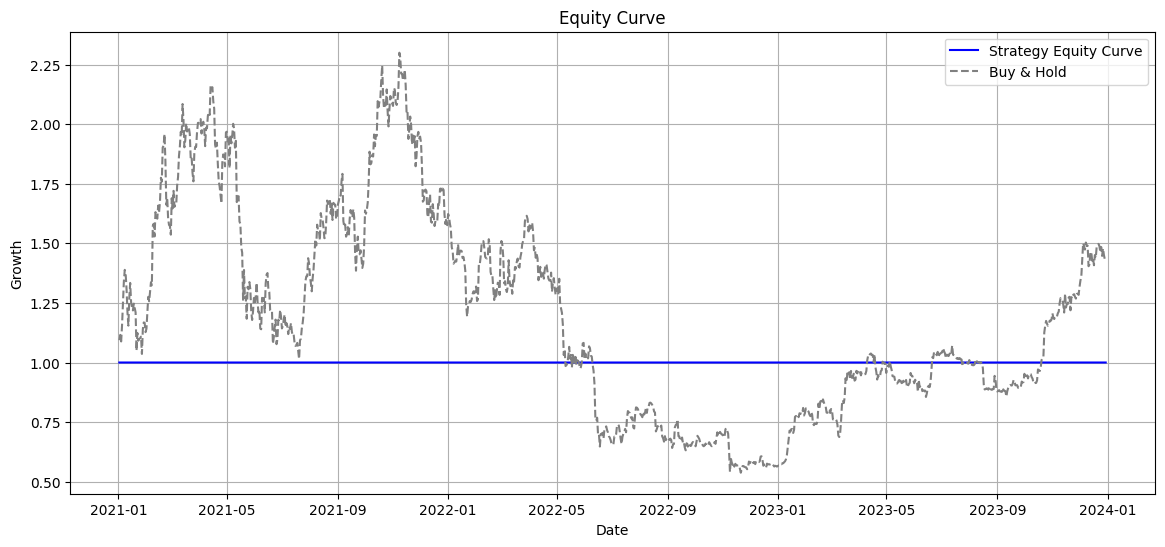

In [7]:
df = generate_signals(data.copy())
df = backtest(df)
plot_equity(df)


In [8]:
total_return = df['Equity_Curve'].iloc[-1] - 1
win_rate = (df['Strategy_Returns'] > 0).sum() / df['Strategy_Returns'].count()
print(f"Total Return: {total_return:.2%}")
print(f"Win Rate: {win_rate:.2%}")


Total Return: 0.00%
Win Rate: 0.00%
